In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataframe = pd.read_csv('/content/Zomato-data-.csv')
print(dataframe.head())

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


In [4]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [5]:
# Removing the denominator column and Make it float without denominator
def handleRate(value):
  value = str(value).split('/')
  value = value[0]
  return float (value)

dataframe['rate'] = dataframe['rate'].apply(handleRate)
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [6]:
# checking for missing null values
dataframe.isnull().sum()

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
approx_cost(for two people),0
listed_in(type),0


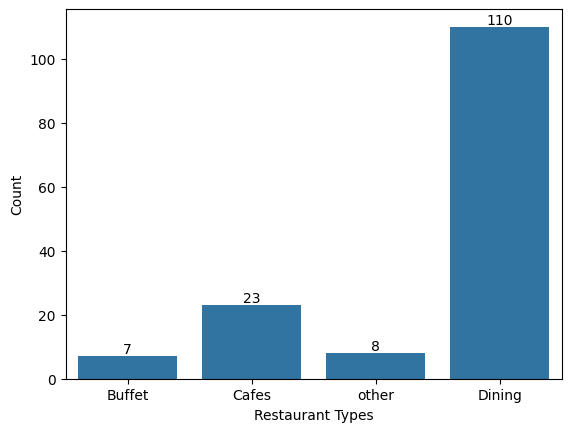

In [11]:
# Exploring restaurant types
ax = sns.countplot(x=dataframe['listed_in(type)'])
plt.xlabel('Restaurant Types')
plt.ylabel('No: of restaurants')
for container in ax.containers:
    ax.bar_label(container)

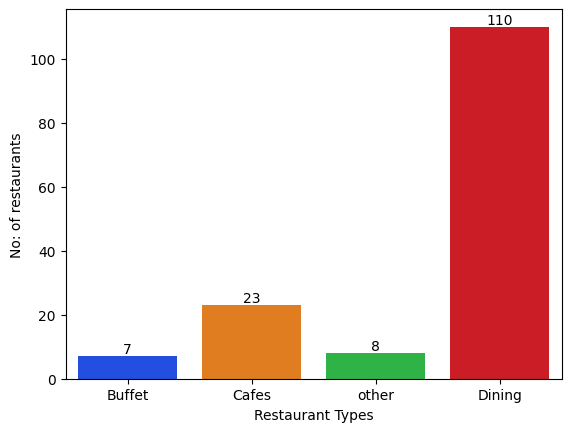

In [17]:
ax = sns.countplot(x=dataframe['listed_in(type)'], hue=dataframe['listed_in(type)'], palette='bright')
plt.xlabel('Restaurant Types')
plt.ylabel('No: of restaurants')
for container in ax.containers:
  ax.bar_label(container)
plt.show()

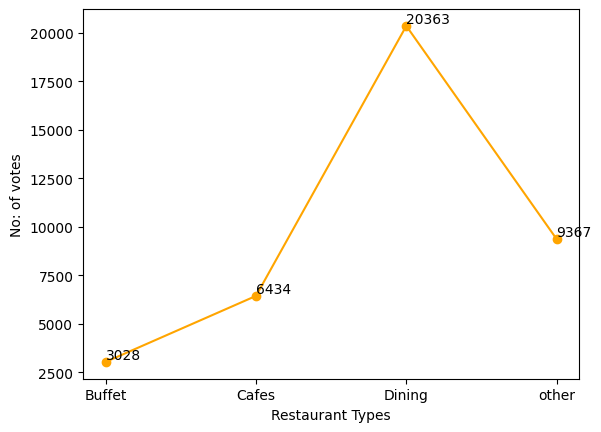

In [31]:
# Votes by restaurant type

groupped_data = dataframe.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes':groupped_data})
plt.plot(result,c='orange',marker='o')
plt.xlabel('Restaurant Types')
plt.ylabel('No: of votes')

# Add the readings above the markers
for index, row in result.iterrows():
    plt.text(index, row['votes'], str(row['votes']), ha='left', va='bottom' ,)

In [37]:
# Identifying the most voted restaurant
most_rated_restaurant = dataframe['votes'].max()
most_rated_restaurant_name = dataframe[dataframe['votes'] == most_rated_restaurant]['name'].values
print(f"The most rated restaurant is {most_rated_restaurant_name} with {most_rated_restaurant} votes")

The most rated restaurant is ['Empire Restaurant'] with 4884 votes


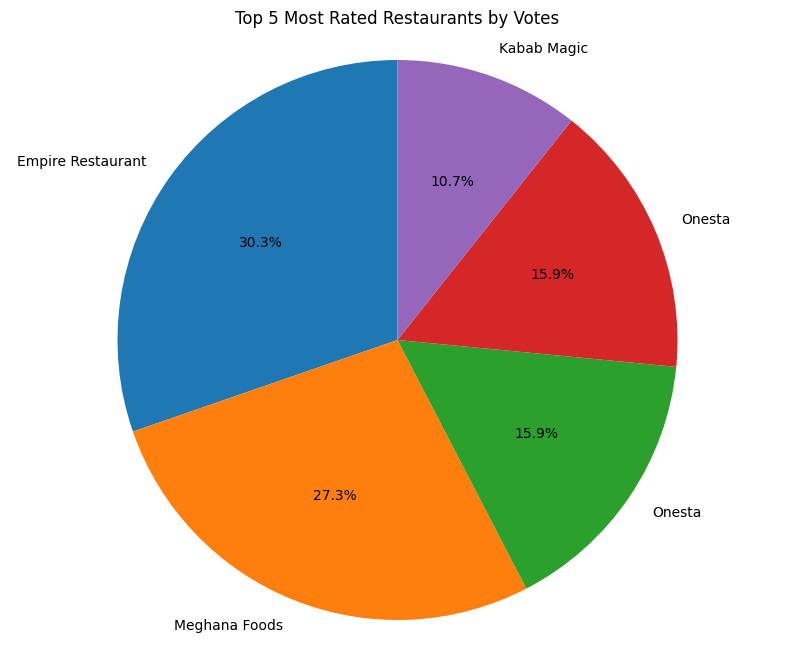

In [36]:
# Identify the top 5 most rated restaurants
top_5_restaurants = dataframe.nlargest(5, 'votes')

labels = top_5_restaurants['name']
sizes = top_5_restaurants['votes']

plt.figure(figsize=(10, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Top 5 Most Rated Restaurants by Votes')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

/tmp/ipykernel_384/30550706.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




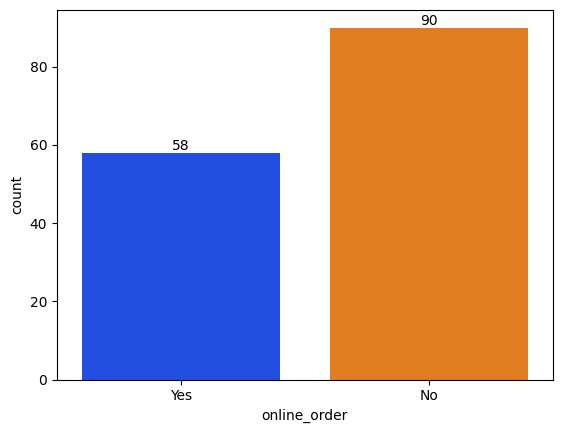

In [39]:
# Online Order Availability
ax = sns.countplot(x=dataframe['online_order'], palette='bright')
for container in ax.containers:
  ax.bar_label(container)


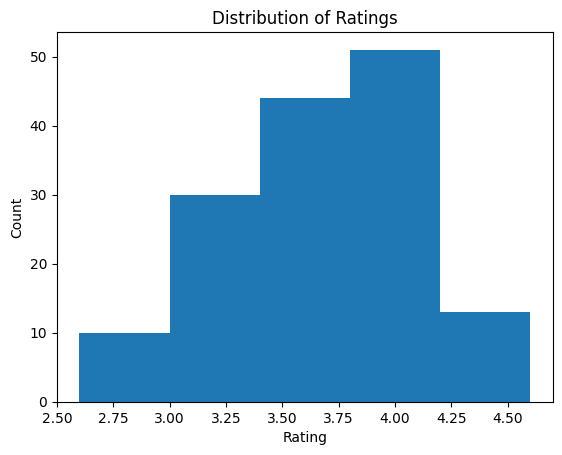

In [43]:
# Analyzing Ratings
plt.hist(dataframe['rate'], bins=5)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_384/3082689689.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




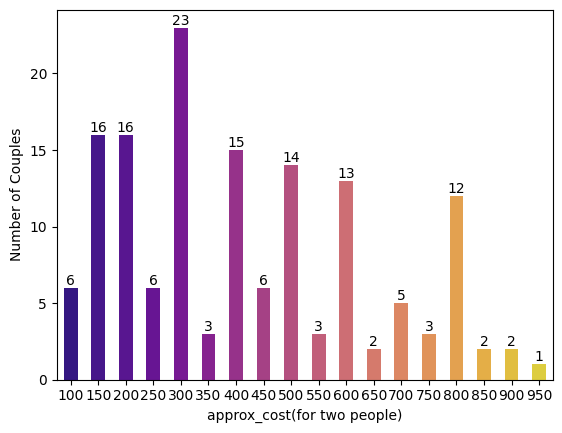

In [51]:
# Approximate cost for couples
couple_data = dataframe['approx_cost(for two people)']
ax = sns.countplot(x = couple_data, palette='plasma')

# Adjust bar width to create gaps
for patch in ax.patches:
    current_width = patch.get_width()
    new_width = 0.5  # You can adjust this value (e.g., 0.3 for more gap, 0.7 for less)
    patch.set_width(new_width)
    # Center the bar
    patch.set_x(patch.get_x() + (current_width - new_width) / 2)

for container in ax.containers:
  ax.bar_label(container)
plt.ylabel('Number of Couples')
plt.show()

/tmp/ipykernel_384/2356341111.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='online_order', ylabel='rate'>

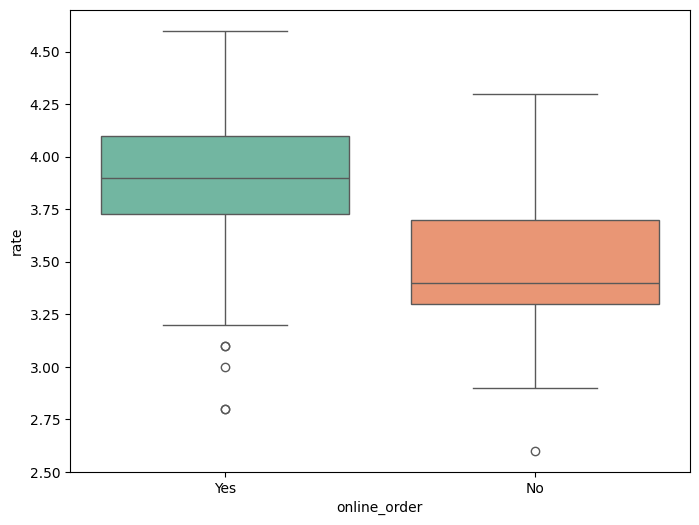

In [53]:
# Rating comparison Online vs Offline
plt.figure(figsize=(8, 6))
sns.boxplot(x='online_order', y='rate', data=dataframe, palette='Set2')

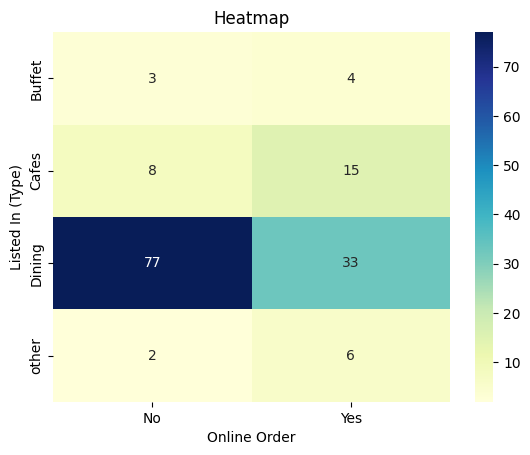

In [54]:
# Order Mode Preference by Restaurant Type
pivot_table = dataframe.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size',fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='g')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Restaurant Type)')
plt.show()